(p2-lab-classification)=
# P2 실습: 분류

**감사의 글**

오렐리앙 제롱<font size='2'>Aurélien Géron</font>의 [Hands-On Machine Learning with Scikit-Learn and PyTorch (O'Reilly, 2025)](https://github.com/ageron/handson-mlp)에 사용된 코드를 참고한 실습 노트북이다. 보다 심화된 이해를 위해 책 원본을 읽을 것을 강력하게 권장한다. 자료를 공개한 오렐리앙 제롱과 일부 그림 자료를 제공해 준 한빛아카데미에게 진심어린 감사를 전한다.

**코드 실행**

[(구글 코랩) P2 실습: 분류](https://colab.research.google.com/github/codingalzi/code-workout-ml/blob/master/p2_lab_classification.ipynb)에서 코드를 실행할 수 있다.

**환경설정**

In [1]:
import sys
import sklearn
from packaging.version import Version

# 파이썬 버전과 scikit-learn 버전 확인
assert sys.version_info >= (3, 10)
assert Version(sklearn.__version__) >= Version("1.6.1")

# 필요한 라이브러리 임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 그래프 스타일 설정
plt.rc('font', size=12)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=12)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

## MNIST 데이터와 분류 문제

### MNIST 데이터셋

MNIST는 0부터 9까지의 손글씨 숫자 이미지 70,000개로 구성된 데이터셋이다.

각 이미지는 `(28, 28)` 크기이며, 모델에는 784개의 픽셀값으로 펼친 입력 데이터로 제공된다.  
타깃은 각 이미지가 나타내는 0부터 9까지의 숫자다.

In [2]:
from sklearn.datasets import fetch_openml

# 처음 실행할 때 인터넷 연결이 필요하다.
mnist = fetch_openml("mnist_784", as_frame=False)

X = mnist.data
y = mnist.target

print("입력 데이터:", X.shape)
print("타깃 데이터:", y.shape)
print("타깃:", np.unique(y))

입력 데이터: (70000, 784)
타깃 데이터: (70000,)
타깃: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']


### 손글씨 이미지 확인

첫 번째 샘플을 `(28, 28)` 모양으로 바꾸어 이미지로 확인한다.

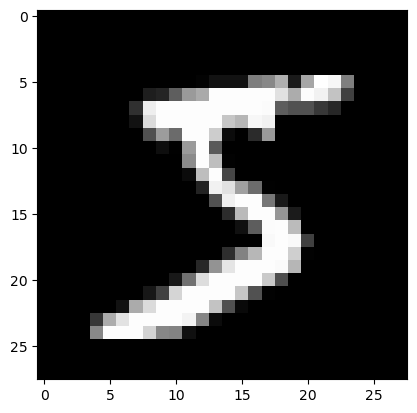

실제 라벨: 5


In [3]:
example_5 = X[0]

plt.imshow(example_5.reshape(28, 28), cmap="gray")
plt.show()

print("실제 라벨:", y[0])

### 훈련셋과 테스트셋

MNIST는 앞의 60,000개 샘플을 훈련셋, 뒤의 10,000개 샘플을 테스트셋으로 사용한다.

MNIST는 이미 훈련셋과 테스트셋에 포함된 각 숫자들의 비율이 일정하도록 구성되어 있다.

테스트셋은 최종 평가 전까지 모델 선택에 사용하지 않는다.

In [4]:
X_train_full, X_test = X[:60000], X[60000:]
y_train_full, y_test = y[:60000], y[60000:]

print("훈련셋:", X_train_full.shape, y_train_full.shape)
print("테스트셋:", X_test.shape, y_test.shape)

훈련셋: (60000, 784) (60000,)
테스트셋: (10000, 784) (10000,)


## 이진 분류와 로지스틱 회귀

### 숫자 5 판별 문제

먼저 **숫자 5인지 아닌지**를 구분하는 이진 분류 문제로 바꾼다.

- 숫자 5 → 양성(`True`)
- 그 밖의 숫자 → 음성(`False`)

In [5]:
y_train_full_5 = (y_train_full == "5")
y_test_5 = (y_test == "5")

훈련셋에서 숫자 5의 비율은 약 9%이다.

In [6]:
print(y_train_full_5.mean())

0.09035


라벨(타깃)은 `False` 또는 `True`로 구성된다. 

In [7]:
y_test_5

array([False, False, False, ..., False,  True, False], shape=(10000,))

### 학습용과 검증용 데이터

테스트셋을 사용하기 전에 훈련셋 일부를 **검증셋**으로 분리한다.

숫자 5의 비율이 유지되도록 무작위 샘플링이 아닌 층화 샘플링을 활용한다.

이번 실습에서 데이터의 역할은 다음과 같다.

- **학습용 데이터**: 로지스틱 회귀의 모델 파라미터를 학습한다.
- **검증용 데이터**: 하이퍼파라미터 `C`와 결정 임곗값을 선택한다.
- **테스트 데이터**: 모든 선택이 끝난 뒤 최종 성능을 한 번 확인한다.

따라서 테스트셋은 모델을 조정하는 과정에서는 사용하지 않는다.

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train_5, y_val_5 = train_test_split(
    X_train_full,
    y_train_full_5,
    test_size=10000,
    stratify=y_train_full_5,
    random_state=42
)

print("학습용:", X_train.shape)
print("검증용:", X_val.shape)

학습용: (50000, 784)
검증용: (10000, 784)


### 로지스틱 회귀 모델

로지스틱 회귀는 입력 특성으로부터 **양성 클래스에 속할 확률**을 계산하고,
그 확률을 기준으로 클래스를 예측하는 분류 모델이다.

픽셀값을 0과 1 사이의 값으로 변환한 뒤 `LogisticRegression`을 훈련한다.
전처리 과정과 모델은 하나의 파이프라인으로 묶는다.

이번에는 모델을 바로 하나 선택하지 않고, 로지스틱 회귀의 하이퍼파라미터인 `C`를
검증셋에서 비교한다.

`C`는 규제의 강도와 관련된 하이퍼파라미터다.

- `C`가 작을수록 규제가 강하다.
- `C`가 클수록 규제가 약하다.

여기서는 `0.1`, `1`, `10` 세 값을 비교한다.

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression

def make_binary_clf(C):
    return make_pipeline(MinMaxScaler(), LogisticRegression(C=C, max_iter=300, tol=1e-3, random_state=42))

### 검증셋으로 하이퍼파라미터를 선택한다

`C`의 각 후보값마다 다음 과정을 반복한다.

1. **학습용 데이터**로 모델을 훈련한다.
2. **검증용 데이터**의 예측 확률을 계산한다.
3. 검증셋의 **로그 손실**(log loss)을 계산한다.

로그 손실이 작을수록 실제 클래스에 더 적절한 확률을 부여한 것이다.

중요한 점은 `C`를 선택할 때 **테스트셋을 사용하지 않는 것**이다.

> **모델 파라미터는 학습셋에서 학습하고, 하이퍼파라미터는 검증셋의 결과를 보고 선택한다.**

In [ ]:
from sklearn.metrics import log_loss

C_values = [0.1, 1.0, 10.0]
tuning_results = []
models_by_C = {}

for C in C_values:
    clf = make_binary_clf(C)
    clf.fit(X_train, y_train_5)

    y_val_proba_C = clf.predict_proba(X_val)
    val_log_loss = log_loss(y_val_5, y_val_proba_C)

    tuning_results.append({"C": C, "Validation Log Loss": val_log_loss})
    models_by_C[C] = clf

tuning_results = pd.DataFrame(tuning_results)
tuning_results

검증 로그 손실이 가장 작은 `C`를 선택한다.

이 선택이 끝나면 이후의 혼동 행렬, 정밀도, 재현율, ROC-AUC와
결정 임곗값 분석은 **선택된 모델**을 이용하여 수행한다.

In [ ]:
best_C = float(tuning_results.loc[tuning_results["Validation Log Loss"].idxmin(), "C"])
binary_clf = models_by_C[best_C]

print("선택한 C:", best_C)

훈련된 로지스틱 회귀 모델이 앞서 살펴본 5를 가리키는 이미지를 숫자 5라고 정확히 예측한다.
즉, 양성 이미지를 양성으로 정확히 판정한다.

In [ ]:

binary_clf.predict([example_5])

### 혼동 행렬

혼동 행렬은 실제값과 예측값을 네 경우로 구분한다.

| | 예측 음성 | 예측 양성 |
|---|---:|---:|
| **실제 음성** | TN (참 음성) | FP (거짓 양성) |
| **실제 양성** | FN (거짓 음성) | TP (참 양성) |

숫자 자체보다 **어떤 종류의 오류가 발생했는지**를 읽는 것이 중요하다.

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_val_pred = binary_clf.predict(X_val)

cm = confusion_matrix(y_val_5, y_val_pred)
cm

In [ ]:
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

### 정확도의 한계

숫자 5는 전체의 약 9%다. 따라서 모든 이미지를 “5가 아니다”라고 예측해도 높은 정확도가 나올 수 있다.

클래스 비율이 불균형한 문제에서는 정확도만으로 모델을 평가하기 어렵다.

In [ ]:
from sklearn.metrics import accuracy_score

never_5_pred = np.zeros_like(y_val_5, dtype=bool)

print(
    "항상 '5가 아니다'라고 예측할 때의 정확도:",
    accuracy_score(y_val_5, never_5_pred)
)

print(
    "로지스틱 회귀 정확도:",
    accuracy_score(y_val_5, y_val_pred)
)

### 정밀도와 재현율

- **정밀도(precision)**: 양성이라고 예측한 것 중 실제 양성의 비율
- **재현율(recall)**: 실제 양성 중 모델이 찾아낸 비율

어떤 지표가 더 중요한지는 문제의 목적에 따라 달라진다.

In [ ]:
from sklearn.metrics import precision_score, recall_score

print("정밀도:", precision_score(y_val_5, y_val_pred))
print("재현율:", recall_score(y_val_5, y_val_pred))

### 예측 확률과 결정 임곗값

`predict_proba()`는 각 클래스에 속할 확률을 반환한다.

양성 클래스의 확률이 일정 기준 이상이면 양성으로 분류할 수 있다.  
이 **결정 임곗값**을 바꾸면 정밀도와 재현율도 달라진다.

로지스틱 회귀 모델의 기본 결정 임곗값은 0.5이다.

In [ ]:
y_val_proba = binary_clf.predict_proba(X_val)
y_val_scores = y_val_proba[:, 1]

print(y_val_proba[:5])

### 정밀도와 재현율의 트레이드오프

정밀도와 재현율은 상호 트레이드오프(trade-off) 관계를 갖는다.

- 임곗값을 높이면 양성으로 판단하는 샘플이 줄어드는 경향이 있다.
    정밀도는 높아지고 재현율은 낮아질 수 있다.
- 임곗값을 낮추면 양성으로 판단하는 샘플이 많아진다. 정밀도는 낮아지고 재현율은 올라갈 수 있다.

아래 코드는 결정 임곗값을 0부터 1까지 변화시킬 때 정밀도와 재현율의 변화를 그래프로 그린다.

In [ ]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(
    y_val_5,
    y_val_scores
)

plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")

plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.legend()
plt.grid()
plt.show()

아래 코드는 앞서 구한 결정 임곗값에 따른 정밀도와 재현율의 트레이드오프 관계를 직접 보여준다.

In [ ]:
plt.plot(recalls, precisions)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid()
plt.show()

### ROC 곡선과 AUC

ROC 곡선은 결정 임곗값을 바꾸면서 다음 두 비율의 관계를 나타낸다.

- **TPR(True Positive Rate)**: 실제 양성 중 양성으로 올바르게 예측한 비율. 재현율과 같다.
- **FPR(False Positive Rate)**: 실제 음성 중 양성으로 잘못 예측한 비율

좋은 분류기는 가능한 한 **TPR은 높고 FPR은 낮아야 한다.**

AUC(Area Under the Curve)는 ROC 곡선 아래의 면적이다.

- `AUC = 1`에 가까울수록 양성과 음성을 잘 구분한다.
- `AUC = 0.5` 정도면 무작위 분류와 비슷하다.

ROC-AUC는 여러 임곗값에서의 분류 성능을 하나의 값으로 요약한다.  
다만 양성 클래스가 매우 드문 문제에서는 ROC-AUC와 함께 **정밀도-재현율 관계도 함께 확인하는 것이 좋다.**

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, roc_thresholds = roc_curve(
    y_val_5,
    y_val_scores
)

roc_auc = roc_auc_score(
    y_val_5,
    y_val_scores
)

plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "--", label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()

print("ROC-AUC:", roc_auc)

### 목표에 맞게 임곗값을 선택한다

예를 들어 정밀도를 약 90% 이상으로 만들고 싶다면 그 조건을 만족하는 임곗값을 찾을 수 있다.

중요한 것은 특정 값 자체가 아니라 **문제의 목적에 맞게 정밀도와 재현율의 균형을 정하는 것**이다.

In [ ]:
target_precision = 0.90

idx = np.argmax(precisions[:-1] >= target_precision)
threshold_for_90_precision = thresholds[idx]

y_val_pred_90 = (y_val_scores >= threshold_for_90_precision)

print("선택한 임곗값:", threshold_for_90_precision)
print("정밀도:", precision_score(y_val_5, y_val_pred_90))
print("재현율:", recall_score(y_val_5, y_val_pred_90))

### 이진 분류 확인

다음을 설명할 수 있는지 확인한다.

- 모델 파라미터와 하이퍼파라미터의 차이
- `C`를 학습셋이 아니라 검증셋의 결과를 보고 선택하는 이유
- 검증 로그 손실이 작은 모델을 선택한다는 의미
- 정확도가 높아도 좋은 분류기라고 단정할 수 없는 이유
- FP와 FN의 차이
- 정밀도와 재현율의 차이
- `predict()`와 `predict_proba()`의 차이
- 결정 임곗값을 바꾸면 결과가 달라지는 이유
- ROC 곡선과 AUC가 무엇을 나타내는지

## 다중 클래스 분류

### 0부터 9까지 분류한다

이제 원래 타깃을 사용하여 10개의 숫자를 구분하는 **다중 클래스 분류**를 수행한다.

학습용과 검증용 데이터도 원래 숫자 라벨을 이용해 다시 나눈다.

In [ ]:
X_train_multi, X_val_multi, y_train_multi, y_val_multi = train_test_split(
    X_train_full,
    y_train_full,
    test_size=10000,
    stratify=y_train_full,
    random_state=42
)

### 소프트맥스 회귀

`LogisticRegression`은 클래스가 여러 개인 경우인 소프트맥스 회귀에도 사용할 수 있다.

각 숫자 클래스에 대한 확률을 계산하고, 가장 높은 확률의 클래스를 최종 예측값으로 선택한다.

In [ ]:
multi_clf = make_pipeline(
    MinMaxScaler(),
    LogisticRegression(
        max_iter=300,
        tol=1e-3,
        random_state=42
    )
)

multi_clf.fit(X_train_multi, y_train_multi)

y_val_multi_pred = multi_clf.predict(X_val_multi)

print(
    "검증 정확도:",
    accuracy_score(y_val_multi, y_val_multi_pred)
)

### 클래스별 예측 확률

몇 개의 샘플에 대해 각 숫자 클래스의 예측 확률을 확인한다.

In [ ]:
sample_proba = multi_clf.predict_proba(X_val_multi[:5])
sample_pred = multi_clf.predict(X_val_multi[:5])

classes = multi_clf.named_steps["logisticregression"].classes_

prob_table = pd.DataFrame(
    sample_proba,
    columns=classes
)

prob_table["predicted"] = sample_pred
prob_table["actual"] = y_val_multi[:5]

prob_table

## 최종 테스트셋에서 확인한다

검증 단계에서 모델과 평가 방법을 모두 정한 뒤 마지막으로 테스트셋을 사용한다.

이진 분류에서는 검증셋에서

- 하이퍼파라미터 `C`
- 목표 정밀도에 맞춘 결정 임곗값

을 이미 선택했다.

이제 이 두 값을 더 이상 바꾸지 않는다.
선택한 `C`를 사용하여 전체 훈련 데이터로 모델을 다시 학습한 뒤,
검증셋에서 정한 임곗값을 테스트셋에 그대로 적용한다.

In [ ]:
binary_clf.fit(X_train_full, y_train_full_5)

test_scores = binary_clf.predict_proba(X_test)[:, 1]
y_test_pred_90 = (test_scores >= threshold_for_90_precision)

print("테스트 정밀도:", precision_score(y_test_5, y_test_pred_90))
print("테스트 재현율:", recall_score(y_test_5, y_test_pred_90))

다중 클래스 분류 모델도 전체 훈련셋으로 다시 학습한 뒤 테스트셋에서 최종 정확도를 계산한다.

In [ ]:
multi_clf.fit(X_train_full, y_train_full)

y_test_multi_pred = multi_clf.predict(X_test)

print(
    "테스트 정확도:",
    accuracy_score(y_test, y_test_multi_pred)
)

## 마무리

이번 실습의 핵심은 다음과 같다.

- 학습셋은 모델 파라미터를 학습하는 데 사용한다.
- 검증셋은 `C`와 같은 하이퍼파라미터와 결정 임곗값을 선택하는 데 사용할 수 있다.
- 테스트셋은 모든 선택이 끝난 뒤 최종 성능을 확인하는 데 사용한다.
- 이진 분류에서는 정확도뿐 아니라 혼동 행렬, 정밀도, 재현율을 함께 본다.
- 로지스틱 회귀는 클래스뿐 아니라 클래스별 확률도 예측할 수 있다.
- 결정 임곗값을 바꾸면 정밀도와 재현율의 균형이 달라진다.
- ROC 곡선과 AUC는 여러 임곗값에서의 분류 성능을 요약한다.
- 같은 로지스틱 회귀 모델로 다중 클래스 분류도 수행할 수 있다.